In [1]:
# Install RF-DETR (official Roboflow package) and supporting libraries
!pip install -q rfdetr roboflow supervision pycocotools matplotlib Pillow
print('✅ All packages installed.')
!pip install -q "rfdetr[train,loggers]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 118.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 10.9 MB/s eta 0:00:00
✅ All packages installed.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
CHECKPOINT_DIR = '/content/drive/MyDrive/CO3_1_RFDETR_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f'✅ Drive mounted. Checkpoints will save to: {CHECKPOINT_DIR}')

Mounted at /content/drive
✅ Drive mounted. Checkpoints will save to: /content/drive/MyDrive/CO3_1_RFDETR_checkpoints


In [4]:
from roboflow import Roboflow

API_KEY = "B9GFnVJTMeFxb9eci8wC"

rf = Roboflow(API_KEY)

project = rf.workspace("universe-datasets").project("hard-hat-universe-0dy7t")
version = project.version(22)
dataset = version.download("coco")

DATASET_DIR = dataset.location
print(f'✅ Dataset downloaded to: {DATASET_DIR}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Hard-Hat-Universe-22 in coco:: 100%|██████████| 6998/6998 [00:03<00:00, 1771.72it/s]

✅ Dataset downloaded to: /content/Hard-Hat-Universe-22


In [5]:
import os, json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

# Check folder structure
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(DATASET_DIR, split)
    ann_file = os.path.join(DATASET_DIR, split, '_annotations.coco.json')
    if os.path.exists(img_dir):
        imgs = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
        with open(ann_file) as f:
            ann_data = json.load(f)
        print(f'{split:8s} → {len(imgs):5d} images | {len(ann_data["annotations"]):6d} annotations | {len(ann_data["categories"])} classes')

# Print class names
with open(os.path.join(DATASET_DIR, 'train', '_annotations.coco.json')) as f:
    train_ann = json.load(f)
classes = {cat['id']: cat['name'] for cat in train_ann['categories']}
print(f'\n📋 Classes: {list(classes.values())}')

train    →  4878 images |  18579 annotations | 3 classes
valid    →  1405 images |   5033 annotations | 3 classes
test     →   707 images |   2645 annotations | 3 classes

📋 Classes: ['Hard-Hats', 'head', 'helmet']


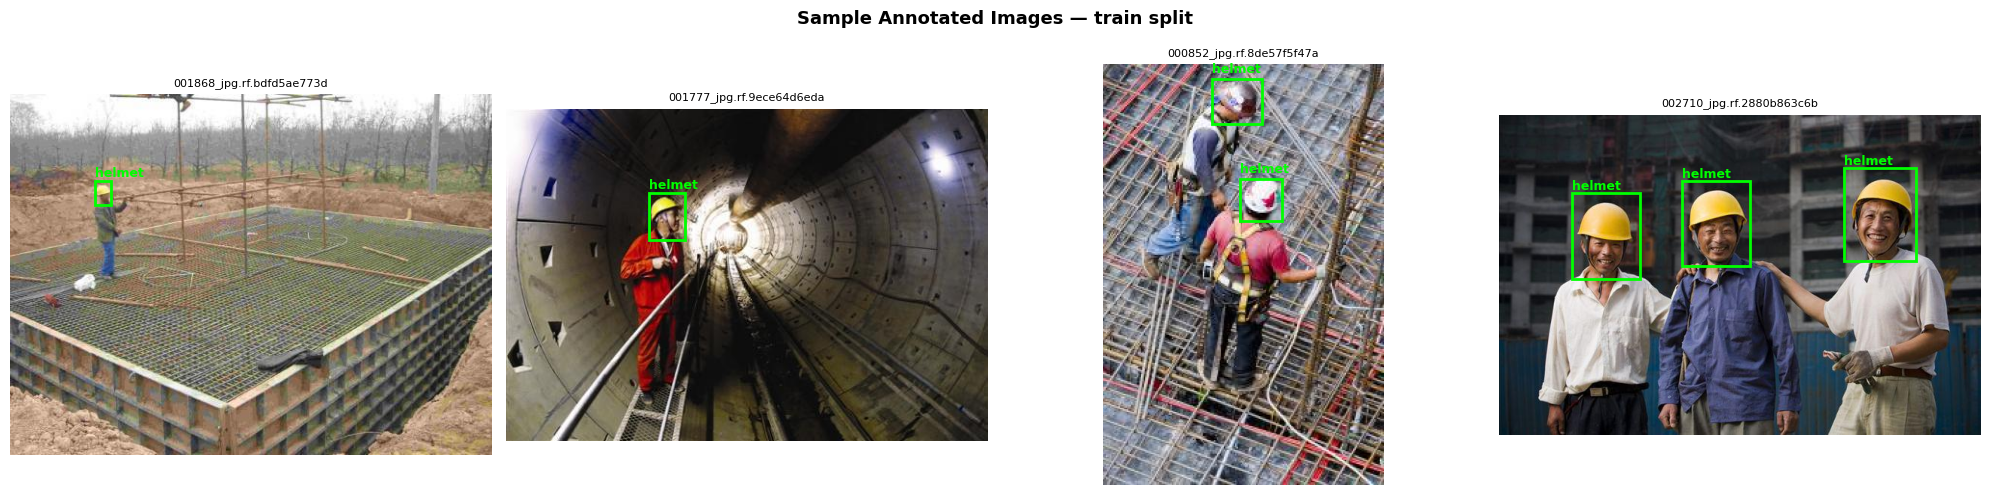

In [6]:
import random

COLORS = {'head': 'red', 'helmet': 'lime', 'person': 'blue'}

def show_annotated_samples(dataset_dir, split='train', n=4):
    ann_file = os.path.join(dataset_dir, split, '_annotations.coco.json')
    img_dir  = os.path.join(dataset_dir, split)
    with open(ann_file) as f:
        data = json.load(f)
    cat_map = {cat['id']: cat['name'] for cat in data['categories']}
    img_map  = {img['id']: img for img in data['images']}
    ann_map  = {}
    for ann in data['annotations']:
        ann_map.setdefault(ann['image_id'], []).append(ann)

    sample_ids = random.sample(list(img_map.keys()), n)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    for ax, img_id in zip(axes, sample_ids):
        img_info = img_map[img_id]
        img_path = os.path.join(img_dir, img_info['file_name'])
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        for ann in ann_map.get(img_id, []):
            x, y, w, h = ann['bbox']
            label = cat_map[ann['category_id']]
            color = COLORS.get(label, 'yellow')
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x, y - 4, label, color=color, fontsize=9, fontweight='bold')
        ax.axis('off')
        ax.set_title(img_info['file_name'][:25], fontsize=8)
    plt.suptitle(f'Sample Annotated Images — {split} split', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_annotated_samples(DATASET_DIR, split='train', n=4)

In [7]:
from rfdetr import RFDETRBase

# RFDETRBase = 29M params — fits in free Colab T4 (15GB VRAM)
# RFDETRLarge = 128M params — needs Colab Pro
model = RFDETRBase()

print('✅ RF-DETR Base model loaded.')
print('Architecture: DINOv2 backbone + Detection Transformer')
print('Parameters: ~29M')

[2026-06-27 15:43:40] [INFO] rf-detr - Downloading pretrained weights for /root/.roboflow/models/rf-detr-base.pth


target=True is deprecated since `v0.8`; use `TargetMode.ARGS_REMAP` instead. Will be removed in `v1.0`.
The `RFDETRBase` was deprecated since v1.7.0. It will be removed in v2.0.0.


/root/.roboflow/models/rf-detr-base.pth:   0%|          | 0.00/355M [00:00<?, ?iB/s]

[2026-06-27 15:43:46] [INFO] rf-detr - MD5 validation successful for /root/.roboflow/models/rf-detr-base.pth
[2026-06-27 15:43:47] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-base.pth already exists with correct MD5 hash.


[2026-06-27 15:43:49] [WARNING] rf-detr - Pretrained weights at '/root/.roboflow/models/rf-detr-base.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.


✅ RF-DETR Base model loaded.
Architecture: DINOv2 backbone + Detection Transformer
Parameters: ~29M


In [9]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

model.train(
    dataset_dir=DATASET_DIR,
    epochs=10,
    batch_size=1,
    grad_accum_steps=16,
    lr=1e-4,
    resolution=560,
    output_dir=CHECKPOINT_DIR,
    early_stopping_patience=5,
)

print('✅ Training complete! Checkpoints saved to Google Drive.')

[2026-06-27 15:55:11] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-base.pth already exists with correct MD5 hash.


[2026-06-27 15:55:12] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 3. The detection head will be re-initialized to 3 classes.
[2026-06-27 15:55:12] [WARNING] rf-detr - Pretrained weights at '/root/.roboflow/models/rf-detr-base.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.
INFO:pytorch_lightning.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitL

[2026-06-27 15:55:12] [INFO] rf-detr - Building Roboflow train dataset with square resize at resolution 560
[2026-06-27 15:55:12] [INFO] rf-detr - Using multi-scale training with square resize and scales: [840]
[2026-06-27 15:55:12] [INFO] rf-detr - Built 1 Albumentations transforms from config


[2026-06-27 15:55:12] [WARNING] rf-detr - Keypoint pipeline: 'HorizontalFlip' performs a horizontal flip but no keypoint flip pairs were configured. The transform has been disabled to prevent incorrect keypoint annotations. Remove 'HorizontalFlip' from your augmentation config or provide keypoint_flip_pairs.


loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
[2026-06-27 15:55:12] [INFO] rf-detr - Building Roboflow val dataset with square resize at resolution 560
[2026-06-27 15:55:12] [INFO] rf-detr - Using multi-scale training with square resize and scales: [840]
[2026-06-27 15:55:12] [INFO] rf-detr - Built 1 Albumentations transforms from config
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


...

Output()

[2026-06-27 16:29:01] [INFO] rf-detr - Best regular checkpoint saved to /content/drive/MyDrive/CO3_1_RFDETR_checkpoints/checkpoint_best_regular.pth (epoch 0, monitor=val/mAP_50_95, value=0.638711)
[2026-06-27 16:29:07] [INFO] rf-detr - Best EMA mAP improved to 0.6462 (epoch 0)
[2026-06-27 17:04:22] [INFO] rf-detr - Best regular checkpoint saved to /content/drive/MyDrive/CO3_1_RFDETR_checkpoints/checkpoint_best_regular.pth (epoch 1, monitor=val/mAP_50_95, value=0.641869)
[2026-06-27 17:04:27] [INFO] rf-detr - Best EMA mAP improved to 0.6629 (epoch 1)
[2026-06-27 17:41:49] [INFO] rf-detr - Best regular checkpoint saved to /content/drive/MyDrive/CO3_1_RFDETR_checkpoints/checkpoint_best_regular.pth (epoch 2, monitor=val/mAP_50_95, value=0.652595)
[2026-06-27 17:41:53] [INFO] rf-detr - Best EMA mAP improved to 0.6695 (epoch 2)
[2026-06-27 18:16:45] [INFO] rf-detr - Best regular checkpoint saved to /content/drive/MyDrive/CO3_1_RFDETR_checkpoints/checkpoint_best_regular.pth (epoch 3, monitor=

INFO:pytorch_lightning.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 630, in _fit_impl
    self._run(model, ckpt_path=ckpt_path, weights_only=weights_only)
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1079, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1123, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 217, in run
    self.advance()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 469, in advance
    self.epoch_loop.run(self._data_fetcher)
  File

TypeError: object of type 'NoneType' has no len()

In [15]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()

# Re-initialize model with best checkpoint weights
from rfdetr import RFDETRBase
model = RFDETRBase(
    pretrain_weights=f"{CHECKPOINT_DIR}/checkpoint_best_regular.pth",
    num_classes=3
)
print("✅ Best checkpoint loaded!")

[2026-06-27 19:07:47] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


✅ Best checkpoint loaded!


In [20]:
import json, os
import numpy as np
from PIL import Image
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

TEST_ANN_FILE = os.path.join(DATASET_DIR, 'test', '_annotations.coco.json')
TEST_IMG_DIR  = os.path.join(DATASET_DIR, 'test')

coco_gt = COCO(TEST_ANN_FILE)
with open(TEST_ANN_FILE) as f:
    test_data = json.load(f)

# Map 0-indexed class_id to actual GT category id
id_remap = {cat['id']: cat['id'] for cat in test_data['categories']}
cat_map  = {cat['id']: cat['name'] for cat in test_data['categories']}

results = []
print(f'Running inference on {len(test_data["images"])} test images...')

for img_info in test_data['images']:
    img_path = os.path.join(TEST_IMG_DIR, img_info['file_name'])
    if not os.path.exists(img_path):
        continue
    img = Image.open(img_path).convert('RGB')
    det = model.predict(img, threshold=0.5)

    if det is None or len(det.xyxy) == 0:
        continue

    for i in range(len(det.xyxy)):
        x1, y1, x2, y2 = det.xyxy[i]
        score   = float(det.confidence[i])
        cat_id  = int(det.class_id[i])  # 0-indexed, matches GT directly
        results.append({
            'image_id':    img_info['id'],
            'category_id': cat_id,
            'bbox':        [float(x1), float(y1), float(x2-x1), float(y2-y1)],
            'score':       score
        })

print(f'Total detections: {len(results)}')

if results:
    coco_dt = coco_gt.loadRes(results)
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    map50_95 = coco_eval.stats[0]
    map50    = coco_eval.stats[1]
    print(f'\n📈 mAP@0.50:0.95 = {map50_95:.4f}')
    print(f'📈 mAP@0.50      = {map50:.4f}')
else:
    print('⚠️ No detections found.')

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Running inference on 707 test images...
Total detections: 2477
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.99s).
Accumulating evaluation results...
DONE (t=0.15s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.624
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.911
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.766
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.520
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.693
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.709
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.192
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.659
 A

In [21]:
def compute_iou(box1, box2):
    """Compute IoU between two boxes in [x1, y1, x2, y2] format."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

IOU_THRESHOLD = 0.5
class_stats = {name: {'TP': 0, 'FP': 0, 'FN': 0} for name in cat_map.values()}

# Build GT dict
gt_by_img = {}
for ann in test_data['annotations']:
    gt_by_img.setdefault(ann['image_id'], []).append(ann)

# Build pred dict
pred_by_img = {}
for r in results:
    pred_by_img.setdefault(r['image_id'], []).append(r)

for img_info in test_data['images']:
    img_id = img_info['id']
    gts   = gt_by_img.get(img_id, [])
    preds = sorted(pred_by_img.get(img_id, []), key=lambda x: -x['score'])
    matched_gt = set()

    for pred in preds:
        px1, py1, pw, ph = pred['bbox']
        pred_box = [px1, py1, px1+pw, py1+ph]
        pred_cls = pred['category_id']
        pred_name = cat_map.get(pred_cls, 'unknown')
        best_iou, best_gt_idx = 0, -1

        for gi, gt in enumerate(gts):
            if gi in matched_gt or gt['category_id'] != pred_cls:
                continue
            gx, gy, gw, gh = gt['bbox']
            gt_box = [gx, gy, gx+gw, gy+gh]
            iou = compute_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou, best_gt_idx = iou, gi

        if best_iou >= IOU_THRESHOLD:
            class_stats[pred_name]['TP'] += 1
            matched_gt.add(best_gt_idx)
        else:
            class_stats[pred_name]['FP'] += 1

    # FN: GT boxes not matched
    for gi, gt in enumerate(gts):
        if gi not in matched_gt:
            gt_name = cat_map.get(gt['category_id'], 'unknown')
            class_stats[gt_name]['FN'] += 1

# --- Print results table ---
print(f'\n{"Class":<12} {"TP":>6} {"FP":>6} {"FN":>6} {"Precision":>10} {"Recall":>10} {"F1":>8}')
print('-' * 62)
all_tp = all_fp = all_fn = 0
for cls_name, s in class_stats.items():
    tp, fp, fn = s['TP'], s['FP'], s['FN']
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0
    print(f'{cls_name:<12} {tp:>6} {fp:>6} {fn:>6} {prec:>10.4f} {rec:>10.4f} {f1:>8.4f}')
    all_tp += tp; all_fp += fp; all_fn += fn

print('-' * 62)
overall_prec = all_tp / (all_tp + all_fp) if (all_tp + all_fp) > 0 else 0
overall_rec  = all_tp / (all_tp + all_fn) if (all_tp + all_fn) > 0 else 0
overall_f1   = 2*overall_prec*overall_rec / (overall_prec+overall_rec) if (overall_prec+overall_rec) > 0 else 0
accuracy     = all_tp / (all_tp + all_fp + all_fn) if (all_tp + all_fp + all_fn) > 0 else 0
print(f'{"OVERALL":<12} {all_tp:>6} {all_fp:>6} {all_fn:>6} {overall_prec:>10.4f} {overall_rec:>10.4f} {overall_f1:>8.4f}')
print(f'\n🎯 Classification Accuracy (IoU≥0.5): {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'📈 mAP@0.50 (from COCO eval above)  : {map50:.4f}')


Class            TP     FP     FN  Precision     Recall       F1
--------------------------------------------------------------
Hard-Hats         0      0      0     0.0000     0.0000   0.0000
head            675     39     46     0.9454     0.9362   0.9408
helmet         1738     25    186     0.9858     0.9033   0.9428
--------------------------------------------------------------
OVERALL        2413     64    232     0.9742     0.9123   0.9422

🎯 Classification Accuracy (IoU≥0.5): 0.8907 (89.07%)
📈 mAP@0.50 (from COCO eval above)  : 0.9109


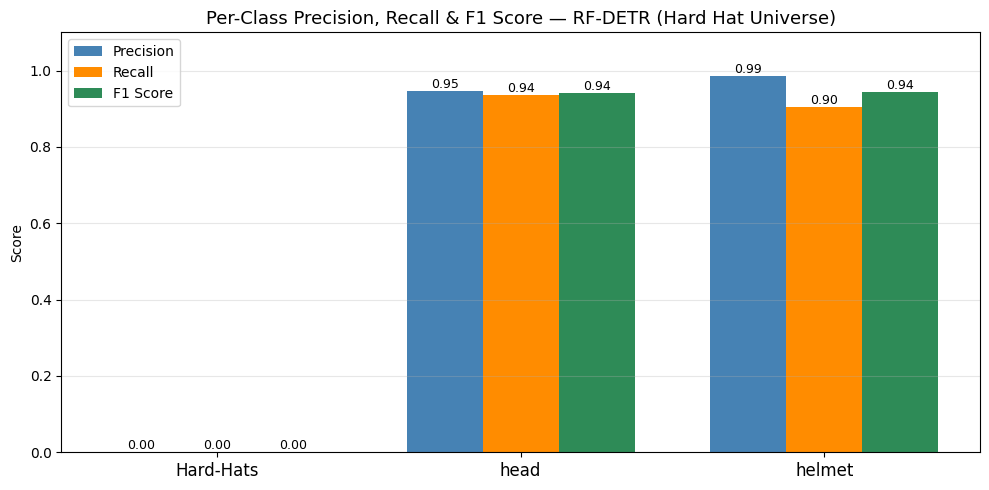

✅ Chart saved to /content/metrics_chart.png


In [22]:
import matplotlib.pyplot as plt
import numpy as np

cls_names, precisions, recalls, f1s = [], [], [], []
for cls_name, s in class_stats.items():
    tp, fp, fn = s['TP'], s['FP'], s['FN']
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0
    cls_names.append(cls_name)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

x = np.arange(len(cls_names))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, precisions, width, label='Precision', color='steelblue')
ax.bar(x,         recalls,    width, label='Recall',    color='darkorange')
ax.bar(x + width, f1s,        width, label='F1 Score',  color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(cls_names, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision, Recall & F1 Score — RF-DETR (Hard Hat Universe)', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.2f}',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('/content/metrics_chart.png', dpi=150)
plt.show()
print('✅ Chart saved to /content/metrics_chart.png')

## 🖼️ CELL 11 — Visualize Predictions on Test Images

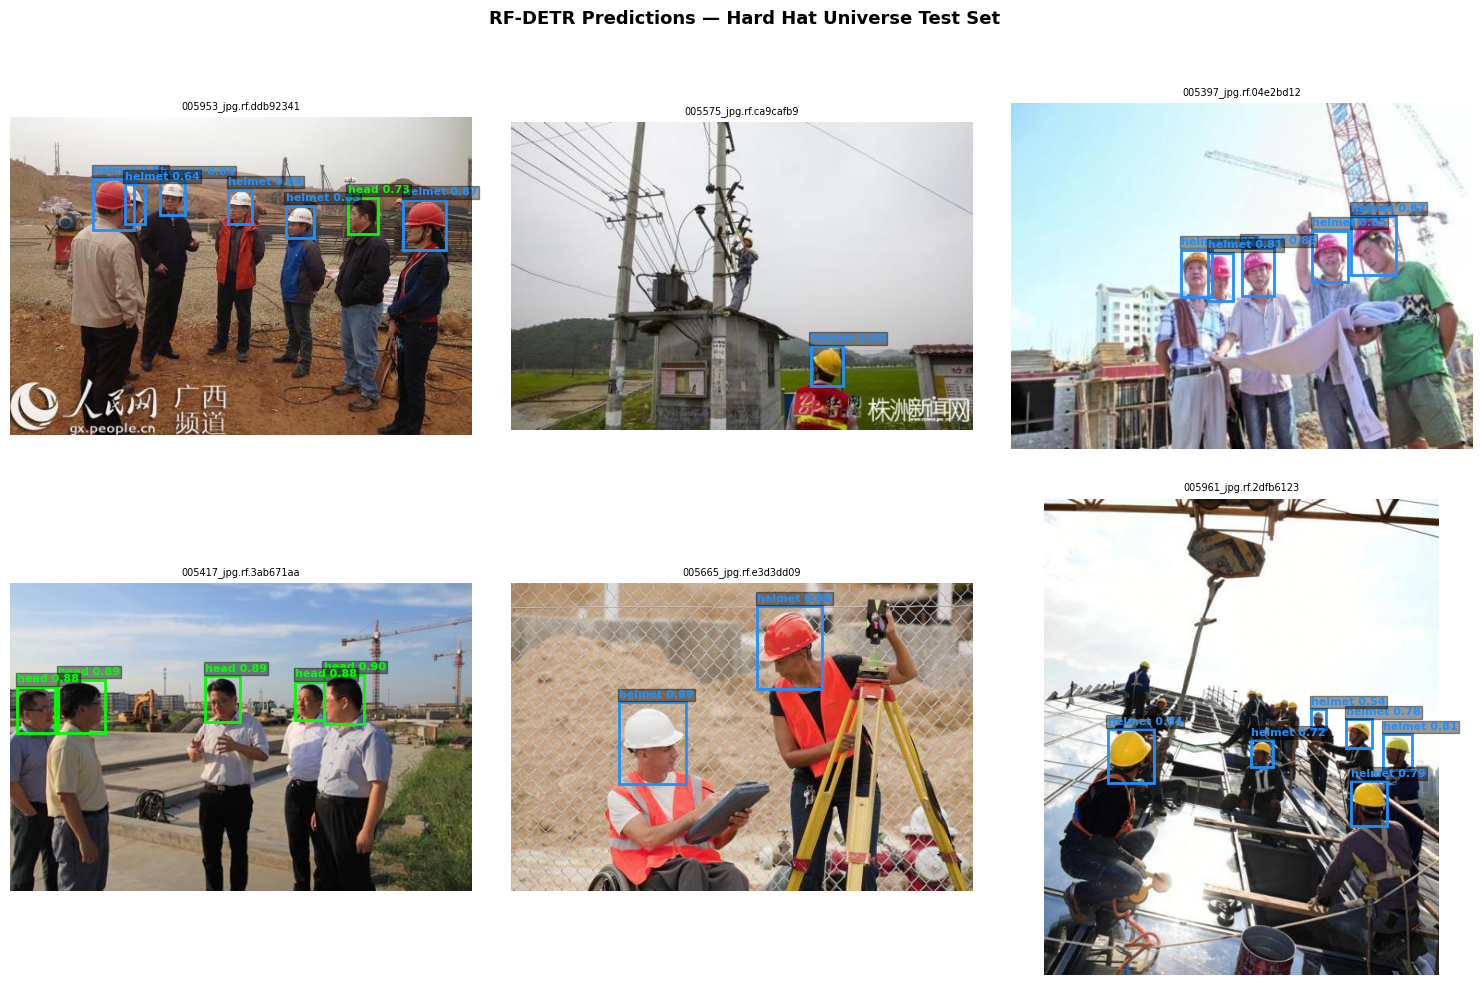

✅ Visualization saved to /content/predictions_viz.png


In [24]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

PRED_COLORS = {0: 'red', 1: 'lime', 2: 'dodgerblue'}
CLASS_NAMES = {0: 'Hard-Hats', 1: 'head', 2: 'helmet'}

def visualize_predictions(dataset_dir, model, split='test', n=6, threshold=0.5):
    ann_file = os.path.join(dataset_dir, split, '_annotations.coco.json')
    img_dir  = os.path.join(dataset_dir, split)
    with open(ann_file) as f:
        data = json.load(f)

    sample_imgs = random.sample(data['images'], min(n, len(data['images'])))
    fig, axes = plt.subplots(2, n//2, figsize=(5*(n//2), 10))
    axes = axes.flatten()

    for ax, img_info in zip(axes, sample_imgs):
        img_path = os.path.join(img_dir, img_info['file_name'])
        img = Image.open(img_path).convert('RGB')
        det = model.predict(img, threshold=threshold)
        ax.imshow(img)

        if det is not None and len(det.xyxy) > 0:
            for i in range(len(det.xyxy)):
                x1, y1, x2, y2 = det.xyxy[i]
                score  = float(det.confidence[i])
                cls_id = int(det.class_id[i])
                label  = CLASS_NAMES.get(cls_id, 'unknown')
                color  = PRED_COLORS.get(cls_id, 'yellow')
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                          linewidth=2, edgecolor=color, facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1-5, f'{label} {score:.2f}',
                        color=color, fontsize=8, fontweight='bold',
                        bbox=dict(facecolor='black', alpha=0.4, pad=1))
        ax.axis('off')
        ax.set_title(img_info['file_name'][:22], fontsize=7)

    plt.suptitle('RF-DETR Predictions — Hard Hat Universe Test Set', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/predictions_viz.png', dpi=150)
    plt.show()
    print('✅ Visualization saved to /content/predictions_viz.png')

visualize_predictions(DATASET_DIR, model, split='test', n=6, threshold=0.5)

In [25]:
import shutil

OUTPUT_DIR = '/content/drive/MyDrive/CO3_1_RFDETR_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save charts
shutil.copy('/content/metrics_chart.png',    os.path.join(OUTPUT_DIR, 'metrics_chart.png'))
shutil.copy('/content/predictions_viz.png',  os.path.join(OUTPUT_DIR, 'predictions_viz.png'))

# Save metrics summary as txt
summary_path = os.path.join(OUTPUT_DIR, 'metrics_summary.txt')
with open(summary_path, 'w') as f:
    f.write('=== RF-DETR Evaluation Results — Hard Hat Universe ===\n\n')
    f.write(f'mAP@0.50:0.95 = {map50_95:.4f}\n')
    f.write(f'mAP@0.50      = {map50:.4f}\n')
    f.write(f'Accuracy      = {accuracy:.4f}\n')
    f.write(f'Overall Precision = {overall_prec:.4f}\n')
    f.write(f'Overall Recall    = {overall_rec:.4f}\n')
    f.write(f'Overall F1        = {overall_f1:.4f}\n\n')
    f.write('Per-class breakdown:\n')
    for cls_name, s in class_stats.items():
        tp, fp, fn = s['TP'], s['FP'], s['FN']
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0
        f.write(f'  {cls_name}: Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}\n')

print(f'✅ All outputs saved to Google Drive: {OUTPUT_DIR}')
print('Files saved:')
for fname in os.listdir(OUTPUT_DIR):
    print(f'  - {fname}')

✅ All outputs saved to Google Drive: /content/drive/MyDrive/CO3_1_RFDETR_outputs
Files saved:
  - metrics_chart.png
  - predictions_viz.png
  - metrics_summary.txt
